# German Credit Risk Modelling and Independent Validation

This notebook implements a compact, model-risk-style credit-risk analysis using the German Credit (Statlog) variable schema.

Key constraints followed:
- Target: `kredit`
- Original German predictor names preserved
- No invented English meanings; mappings follow documented Statlog/UCI definitions
- Stratified development/holdout design with untouched holdout for final validation only
- Evaluation covers discrimination, calibration, stability, interpretability, and robustness

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    roc_curve,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
np.random.seed(42)

sns.set_theme(style="whitegrid")

In [2]:
# Data location: user requested data/german_credit_data.csv.
# Fallback keeps this notebook executable in workspaces where the same CSV sits at root.
primary_path = Path("data/german_credit_data.csv")
fallback_path = Path("german_credit_data.csv")

if primary_path.exists():
    data_path = primary_path
elif fallback_path.exists():
    data_path = fallback_path
    print("Note: data/german_credit_data.csv not found here; using german_credit_data.csv in workspace root.")
else:
    raise FileNotFoundError("Could not find german_credit_data.csv in data/ or workspace root.")

raw = pd.read_csv(data_path)
print(f"Data path: {data_path}")
print(f"Shape: {raw.shape}")
raw.head()

Note: data/german_credit_data.csv not found here; using german_credit_data.csv in workspace root.
Data path: german_credit_data.csv
Shape: (1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


In [3]:
expected_predictors = [
    "laufkont", "laufzeit", "moral", "verw", "hoehe", "sparkont", "beszeit", "rate", "famges", "buerge",
    "wohnzeit", "verm", "alter", "weitkred", "wohn", "bishkred", "beruf", "pers", "telef", "gastarb"
]
expected_columns = expected_predictors + ["kredit"]

print("Columns match expected schema:", list(raw.columns) == expected_columns)
print("\nDtypes:")
display(raw.dtypes.to_frame("dtype"))

missing = raw.isna().sum().to_frame("missing_count")
missing["missing_pct"] = 100 * missing["missing_count"] / len(raw)
display(missing)

print("Target distribution (raw kredit values):")
display(raw["kredit"].value_counts(dropna=False).sort_index().rename("count").to_frame())
display((raw["kredit"].value_counts(normalize=True).sort_index() * 100).rename("pct").to_frame())

Columns match expected schema: True

Dtypes:


,dtype
laufkont,int64
laufzeit,int64
moral,int64
verw,int64
hoehe,int64
sparkont,int64
beszeit,int64
rate,int64
famges,int64
buerge,int64


,missing_count,missing_pct
laufkont,0,0.0
laufzeit,0,0.0
moral,0,0.0
verw,0,0.0
hoehe,0,0.0
sparkont,0,0.0
beszeit,0,0.0
rate,0,0.0
famges,0,0.0
buerge,0,0.0


Target distribution (raw kredit values):


,count
kredit,
0,300
1,700


,pct
kredit,
0,30.0
1,70.0


## Documentation-grounded feature mapping and target coding

The following mapping aligns each German column to Statlog/UCI attribute definitions (same attribute order as the documented dataset).

Target coding check:
- UCI/Statlog documentation defines class labels as `1 = good`, `2 = bad`.
- In this CSV, target values are binary (`0/1`).
- We verify empirical class proportions against the documented dataset balance (700 good / 300 bad) and set modelling target as `bad_risk = 1`.

In [4]:
feature_docs = {
    "laufkont": "Status of existing checking account (Attr 1)",
    "laufzeit": "Duration in months (Attr 2)",
    "moral": "Credit history (Attr 3)",
    "verw": "Purpose (Attr 4)",
    "hoehe": "Credit amount (Attr 5)",
    "sparkont": "Savings account/bonds (Attr 6)",
    "beszeit": "Present employment since (Attr 7)",
    "rate": "Installment rate as % of disposable income (Attr 8)",
    "famges": "Personal status and sex (Attr 9)",
    "buerge": "Other debtors/guarantors (Attr 10)",
    "wohnzeit": "Present residence since (Attr 11)",
    "verm": "Property (Attr 12)",
    "alter": "Age in years (Attr 13)",
    "weitkred": "Other installment plans (Attr 14)",
    "wohn": "Housing (Attr 15)",
    "bishkred": "Number of existing credits at this bank (Attr 16)",
    "beruf": "Job (Attr 17)",
    "pers": "Number of people liable for maintenance (Attr 18)",
    "telef": "Telephone (Attr 19)",
    "gastarb": "Foreign worker (Attr 20)",
}

numeric_features = ["laufzeit", "hoehe", "rate", "wohnzeit", "alter", "bishkred", "pers"]
categorical_features = [
    "laufkont", "moral", "verw", "sparkont", "beszeit", "famges", "buerge", "verm",
    "weitkred", "wohn", "beruf", "telef", "gastarb"
]

unique_target_values = sorted(raw["kredit"].dropna().unique().tolist())
assert unique_target_values == [0, 1], f"Unexpected target coding: {unique_target_values}"

# Statlog documents 1=good, 2=bad with roughly 70/30 class split.
# This CSV uses 0/1; empirical 70/30 indicates 1~good and 0~bad.
target_counts = raw["kredit"].value_counts().sort_index()
good_label = int(target_counts.idxmax())
bad_label = 1 - good_label

raw["bad_risk"] = (raw["kredit"] == bad_label).astype(int)

feature_audit = pd.DataFrame({
    "column": expected_predictors,
    "documented_definition": [feature_docs[c] for c in expected_predictors],
    "model_type": ["numeric" if c in numeric_features else "categorical_code" for c in expected_predictors],
    "n_unique": [raw[c].nunique(dropna=True) for c in expected_predictors],
})

print(f"Inferred coding from this CSV: kredit={good_label} -> GOOD, kredit={bad_label} -> BAD")
print(f"Bad-risk event rate (bad_risk=1): {raw['bad_risk'].mean():.3f}")
display(feature_audit)

display(raw["bad_risk"].value_counts().rename("count").to_frame())

Inferred coding from this CSV: kredit=1 -> GOOD, kredit=0 -> BAD
Bad-risk event rate (bad_risk=1): 0.300


,column,documented_definition,model_type,n_unique
0,laufkont,Status of existing checking account (Attr 1),categorical_code,4
1,laufzeit,Duration in months (Attr 2),numeric,33
2,moral,Credit history (Attr 3),categorical_code,5
3,verw,Purpose (Attr 4),categorical_code,10
4,hoehe,Credit amount (Attr 5),numeric,923
5,sparkont,Savings account/bonds (Attr 6),categorical_code,5
6,beszeit,Present employment since (Attr 7),categorical_code,5
7,rate,Installment rate as % of disposable income (At...,numeric,4
8,famges,Personal status and sex (Attr 9),categorical_code,4
9,buerge,Other debtors/guarantors (Attr 10),categorical_code,3


,count
bad_risk,
0,700
1,300


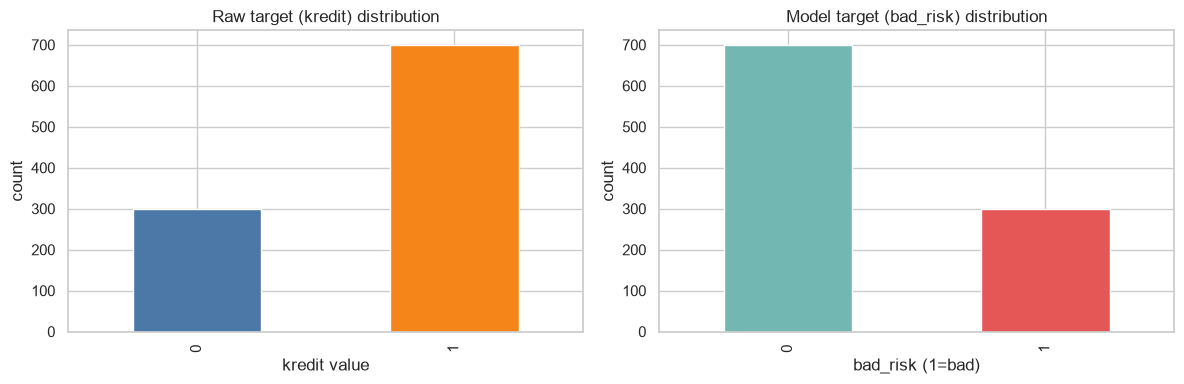

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw["kredit"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Raw target (kredit) distribution")
axes[0].set_xlabel("kredit value")
axes[0].set_ylabel("count")

raw["bad_risk"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#72B7B2", "#E45756"])
axes[1].set_title("Model target (bad_risk) distribution")
axes[1].set_xlabel("bad_risk (1=bad)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Development/holdout split and leakage-safe preprocessing

Split policy:
- 75% development set (for CV, model comparison, threshold/cost analysis)
- 25% untouched holdout (final independent validation only)

`bad_risk=1` is treated as the event class throughout.

In [6]:
X = raw[expected_predictors].copy()
y = raw["bad_risk"].copy()

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Development shape:", X_dev.shape, "Holdout shape:", X_holdout.shape)
print("Development bad-rate:", y_dev.mean().round(3), "Holdout bad-rate:", y_holdout.mean().round(3))

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)

primary_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=4000, solver="lbfgs", random_state=42)),
    ]
)

challenger_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=600,
                min_samples_leaf=8,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

Development shape: (750, 20) Holdout shape: (250, 20)
Development bad-rate: 0.3 Holdout bad-rate: 0.3


In [7]:
def ks_statistic(y_true: pd.Series | np.ndarray, y_prob: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))


def metric_frame(y_true: pd.Series | np.ndarray, y_prob: np.ndarray, model_name: str, sample_name: str) -> pd.DataFrame:
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    ll = log_loss(y_true, np.clip(y_prob, 1e-9, 1 - 1e-9))
    return pd.DataFrame(
        [{
            "model": model_name,
            "sample": sample_name,
            "roc_auc": auc,
            "gini": gini,
            "ks": ks,
            "brier": brier,
            "log_loss": ll,
        }]
    )


def crossval_oof(pipeline: Pipeline, X_data: pd.DataFrame, y_data: pd.Series, model_name: str, n_splits: int = 5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_rows = []
    oof_prob = np.zeros(len(X_data), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_data, y_data), start=1):
        model = clone(pipeline)
        model.fit(X_data.iloc[tr_idx], y_data.iloc[tr_idx])
        p = model.predict_proba(X_data.iloc[va_idx])[:, 1]
        oof_prob[va_idx] = p

        mf = metric_frame(y_data.iloc[va_idx], p, model_name=model_name, sample_name=f"fold_{fold}")
        mf["fold"] = fold
        fold_rows.append(mf)

    fold_metrics = pd.concat(fold_rows, ignore_index=True)
    summary = (
        fold_metrics[["roc_auc", "gini", "ks", "brier", "log_loss"]]
        .agg(["mean", "std"]) 
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )
    summary.insert(0, "model", model_name)
    return fold_metrics, summary, oof_prob

In [8]:
logit_fold_metrics, logit_cv_summary, logit_oof = crossval_oof(primary_model, X_dev, y_dev, model_name="LogisticRegression")
rf_fold_metrics, rf_cv_summary, rf_oof = crossval_oof(challenger_model, X_dev, y_dev, model_name="RandomForest")

cv_summary = pd.concat([logit_cv_summary, rf_cv_summary], ignore_index=True)
cv_fold_all = pd.concat([logit_fold_metrics, rf_fold_metrics], ignore_index=True)

print("5-fold CV summary (development set):")
display(cv_summary)

print("Fold-level stability view:")
display(cv_fold_all[["model", "fold", "roc_auc", "gini", "ks", "brier", "log_loss"]].sort_values(["model", "fold"]))

5-fold CV summary (development set):


,model,metric,mean,std
0,LogisticRegression,roc_auc,0.789376,0.050706
1,LogisticRegression,gini,0.578751,0.101411
2,LogisticRegression,ks,0.478095,0.101130
3,LogisticRegression,brier,0.167169,0.020574
4,LogisticRegression,log_loss,0.507554,0.061596
5,RandomForest,roc_auc,0.782053,0.026515
6,RandomForest,gini,0.564106,0.053030
7,RandomForest,ks,0.477460,0.042627
8,RandomForest,brier,0.171850,0.005529
9,RandomForest,log_loss,0.515827,0.013346


Fold-level stability view:


,model,fold,roc_auc,gini,ks,brier,log_loss
0,LogisticRegression,1,0.845503,0.691005,0.574603,0.142055,0.440604
1,LogisticRegression,2,0.795344,0.590688,0.523810,0.167554,0.504467
2,LogisticRegression,3,0.798095,0.596190,0.453968,0.167471,0.495018
3,LogisticRegression,4,0.706455,0.412910,0.314286,0.198925,0.608498
4,LogisticRegression,5,0.801481,0.602963,0.523810,0.159841,0.489182
5,RandomForest,1,0.802540,0.605079,0.507937,0.168889,0.512587
6,RandomForest,2,0.768466,0.536931,0.457143,0.174869,0.524200
7,RandomForest,3,0.776931,0.553862,0.447619,0.171097,0.510770
8,RandomForest,4,0.748148,0.496296,0.438095,0.179395,0.533201
9,RandomForest,5,0.814180,0.628360,0.536508,0.165002,0.498378


In [9]:
def threshold_table(y_true: pd.Series, y_prob: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else np.nan

        # Cost matrix from Statlog docs (actual rows, predicted columns):
        # Good->Bad: 1, Bad->Good: 5
        total_cost = (1 * fp) + (5 * fn)

        rows.append(
            {
                "threshold": t,
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
                "sensitivity_bad": sensitivity,
                "specificity_good": specificity,
                "precision_bad": precision,
                "total_cost": total_cost,
                "cost_per_100": 100 * total_cost / len(y_true),
            }
        )

    return pd.DataFrame(rows)

threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
logit_threshold_dev = threshold_table(y_dev, logit_oof, threshold_grid)
selected_threshold = float(logit_threshold_dev.loc[logit_threshold_dev["total_cost"].idxmin(), "threshold"])

print(f"Cost-minimizing threshold on development OOF: {selected_threshold:.2f}")
display(logit_threshold_dev.head(10))

display(logit_threshold_dev.sort_values("total_cost").head(5))

Cost-minimizing threshold on development OOF: 0.10


,threshold,tp,fp,tn,fn,sensitivity_bad,specificity_good,precision_bad,total_cost,cost_per_100
0,0.05,219,407,118,6,0.973333,0.224762,0.349840,437,58.266667
1,0.10,207,323,202,18,0.920000,0.384762,0.390566,413,55.066667
2,0.15,192,256,269,33,0.853333,0.512381,0.428571,421,56.133333
3,0.20,182,199,326,43,0.808889,0.620952,0.477690,414,55.200000
4,0.25,166,166,359,59,0.737778,0.683810,0.500000,461,61.466667
5,0.30,157,145,380,68,0.697778,0.723810,0.519868,485,64.666667
6,0.35,143,118,407,82,0.635556,0.775238,0.547893,528,70.400000
7,0.40,134,100,425,91,0.595556,0.809524,0.572650,555,74.000000
8,0.45,123,89,436,102,0.546667,0.830476,0.580189,599,79.866667
9,0.50,113,68,457,112,0.502222,0.870476,0.624309,628,83.733333


,threshold,tp,fp,tn,fn,sensitivity_bad,specificity_good,precision_bad,total_cost,cost_per_100
1,0.10,207,323,202,18,0.920000,0.384762,0.390566,413,55.066667
3,0.20,182,199,326,43,0.808889,0.620952,0.477690,414,55.200000
2,0.15,192,256,269,33,0.853333,0.512381,0.428571,421,56.133333
0,0.05,219,407,118,6,0.973333,0.224762,0.349840,437,58.266667
4,0.25,166,166,359,59,0.737778,0.683810,0.500000,461,61.466667


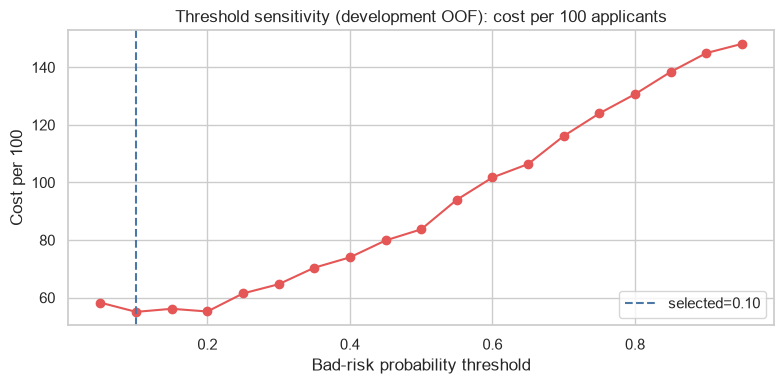

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(logit_threshold_dev["threshold"], logit_threshold_dev["cost_per_100"], marker="o", color="#E45756")
plt.axvline(selected_threshold, color="#4C78A8", linestyle="--", label=f"selected={selected_threshold:.2f}")
plt.title("Threshold sensitivity (development OOF): cost per 100 applicants")
plt.xlabel("Bad-risk probability threshold")
plt.ylabel("Cost per 100")
plt.legend()
plt.tight_layout()
plt.show()

## Final model fitting on development and independent holdout validation

No holdout information is used for model selection, threshold selection, or feature engineering.

In [11]:
primary_fit = clone(primary_model).fit(X_dev, y_dev)
challenger_fit = clone(challenger_model).fit(X_dev, y_dev)

p_dev_logit = primary_fit.predict_proba(X_dev)[:, 1]
p_holdout_logit = primary_fit.predict_proba(X_holdout)[:, 1]

p_dev_rf = challenger_fit.predict_proba(X_dev)[:, 1]
p_holdout_rf = challenger_fit.predict_proba(X_holdout)[:, 1]

perf_dev_holdout = pd.concat(
    [
        metric_frame(y_dev, p_dev_logit, "LogisticRegression", "development_fit"),
        metric_frame(y_holdout, p_holdout_logit, "LogisticRegression", "holdout"),
        metric_frame(y_dev, p_dev_rf, "RandomForest", "development_fit"),
        metric_frame(y_holdout, p_holdout_rf, "RandomForest", "holdout"),
    ],
    ignore_index=True,
)

display(perf_dev_holdout.sort_values(["model", "sample"]))

,model,sample,roc_auc,gini,ks,brier,log_loss
0,LogisticRegression,development_fit,0.848643,0.697287,0.551111,0.139771,0.430574
1,LogisticRegression,holdout,0.753067,0.506133,0.390476,0.175034,0.532165
2,RandomForest,development_fit,0.920914,0.841829,0.674921,0.134102,0.426731
3,RandomForest,holdout,0.780952,0.561905,0.436190,0.170715,0.515934


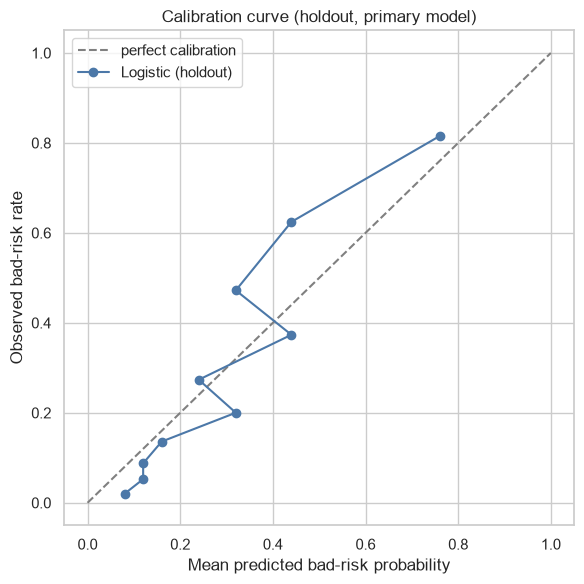

,decile,n,mean_pred_prob,observed_bad_rate,gap_obs_minus_pred
0,1,25,0.020166,0.08,0.059834
1,2,25,0.052513,0.12,0.067487
2,3,25,0.087716,0.12,0.032284
3,4,25,0.136042,0.16,0.023958
4,5,25,0.200199,0.32,0.119801
5,6,25,0.273541,0.24,-0.033541
6,7,25,0.373506,0.44,0.066494
7,8,25,0.472200,0.32,-0.152200
8,9,25,0.624457,0.44,-0.184457
9,10,25,0.815252,0.76,-0.055252


In [12]:
# Holdout calibration diagnostics for primary model
calib_prob, calib_rate = calibration_curve(y_holdout, p_holdout_logit, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
plt.plot(calib_prob, calib_rate, marker="o", color="#4C78A8", label="Logistic (holdout)")
plt.title("Calibration curve (holdout, primary model)")
plt.xlabel("Mean predicted bad-risk probability")
plt.ylabel("Observed bad-risk rate")
plt.legend()
plt.tight_layout()
plt.show()

cal_table = pd.DataFrame({"pred_bad_prob": p_holdout_logit, "actual_bad": y_holdout.values})
cal_table["decile"] = pd.qcut(cal_table["pred_bad_prob"], q=10, labels=False, duplicates="drop") + 1
calibration_table = (
    cal_table.groupby("decile", as_index=False)
    .agg(
        n=("actual_bad", "size"),
        mean_pred_prob=("pred_bad_prob", "mean"),
        observed_bad_rate=("actual_bad", "mean"),
    )
    .sort_values("decile")
)
calibration_table["gap_obs_minus_pred"] = calibration_table["observed_bad_rate"] - calibration_table["mean_pred_prob"]

display(calibration_table)

,risk_band,n,avg_pred_bad_prob,observed_bad_rate
0,Band 1 (lowest risk),50,0.036340,0.10
1,Band 2,50,0.111879,0.14
2,Band 3,50,0.236870,0.28
3,Band 4,50,0.422853,0.38
4,Band 5 (highest risk),50,0.719855,0.60


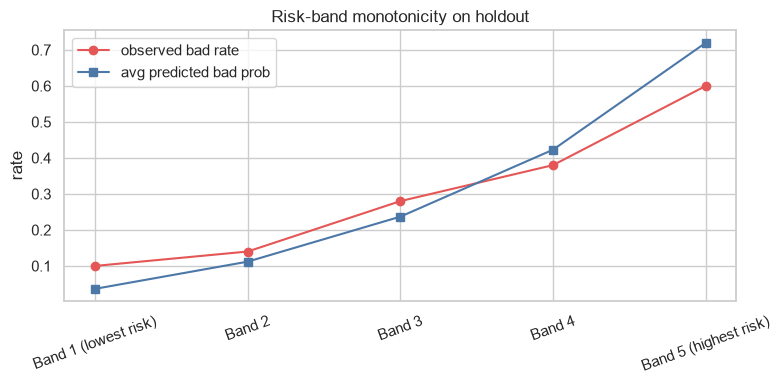

In [13]:
# Holdout risk bands (quintiles)
risk_band_df = pd.DataFrame({"pred_bad_prob": p_holdout_logit, "actual_bad": y_holdout.values})
risk_band_df["risk_band"] = pd.qcut(
    risk_band_df["pred_bad_prob"], q=5, labels=["Band 1 (lowest risk)", "Band 2", "Band 3", "Band 4", "Band 5 (highest risk)"], duplicates="drop"
)

risk_band_table = (
    risk_band_df.groupby("risk_band", as_index=False)
    .agg(
        n=("actual_bad", "size"),
        avg_pred_bad_prob=("pred_bad_prob", "mean"),
        observed_bad_rate=("actual_bad", "mean"),
    )
)

display(risk_band_table)

plt.figure(figsize=(8, 4))
plt.plot(risk_band_table["risk_band"], risk_band_table["observed_bad_rate"], marker="o", label="observed bad rate", color="#E45756")
plt.plot(risk_band_table["risk_band"], risk_band_table["avg_pred_bad_prob"], marker="s", label="avg predicted bad prob", color="#4C78A8")
plt.xticks(rotation=20)
plt.ylabel("rate")
plt.title("Risk-band monotonicity on holdout")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Threshold-based holdout decisions using development-selected threshold
holdout_threshold_eval = threshold_table(y_holdout, p_holdout_logit, np.array([selected_threshold]))
display(holdout_threshold_eval)

# Logistic coefficients / odds ratios
feature_names = primary_fit.named_steps["preprocess"].get_feature_names_out()
coefs = primary_fit.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs),
    "abs_coefficient": np.abs(coefs),
}).sort_values("abs_coefficient", ascending=False)

print("Top logistic effects (by absolute coefficient):")
display(coef_table.head(20))

# Challenger feature importance (RandomForest)
rf_importance_table = pd.DataFrame({
    "feature": feature_names,
    "importance": challenger_fit.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

print("Top challenger importances:")
display(rf_importance_table.head(20))

,threshold,tp,fp,tn,fn,sensitivity_bad,specificity_good,precision_bad,total_cost,cost_per_100
0,0.1,67,110,65,8,0.893333,0.371429,0.378531,150,60.0


Top logistic effects (by absolute coefficient):


,feature,coefficient,odds_ratio,abs_coefficient
17,cat__verw_1,-1.084313,0.338134,1.084313
15,cat__moral_4,-0.978207,0.375985,0.978207
12,cat__moral_1,0.857099,2.356315,0.857099
10,cat__laufkont_4,-0.837728,0.432692,0.837728
16,cat__verw_0,0.831180,2.296026,0.831180
7,cat__laufkont_1,0.737522,2.090747,0.737522
26,cat__sparkont_1,0.667190,1.948754,0.667190
29,cat__sparkont_4,-0.652207,0.520895,0.652207
60,cat__gastarb_2,0.626353,1.870775,0.626353
59,cat__gastarb_1,-0.626195,0.534622,0.626195


Top challenger importances:


,feature,importance
10,cat__laufkont_4,0.132052
1,num__hoehe,0.102348
0,num__laufzeit,0.096519
7,cat__laufkont_1,0.079793
4,num__alter,0.061598
15,cat__moral_4,0.044894
26,cat__sparkont_1,0.031418
2,num__rate,0.027910
8,cat__laufkont_2,0.026866
3,num__wohnzeit,0.022318


In [15]:
# Development-vs-holdout comparison using CV means as development benchmark
cv_mean_wide = (
    cv_summary.pivot(index="model", columns="metric", values="mean")
    .reset_index()
)
holdout_metrics = (
    perf_dev_holdout.loc[perf_dev_holdout["sample"] == "holdout", ["model", "roc_auc", "gini", "ks", "brier", "log_loss"]]
    .rename(columns={
        "roc_auc": "holdout_roc_auc",
        "gini": "holdout_gini",
        "ks": "holdout_ks",
        "brier": "holdout_brier",
        "log_loss": "holdout_log_loss",
    })
)

dev_vs_holdout = cv_mean_wide.merge(holdout_metrics, on="model", how="left")
dev_vs_holdout["auc_shift_holdout_minus_cv"] = dev_vs_holdout["holdout_roc_auc"] - dev_vs_holdout["roc_auc"]
display(dev_vs_holdout)

# Compact final results for resume-quality reporting
primary_holdout = perf_dev_holdout.query("model == 'LogisticRegression' and sample == 'holdout'").iloc[0]
challenger_holdout = perf_dev_holdout.query("model == 'RandomForest' and sample == 'holdout'").iloc[0]

best_dev_cost = float(logit_threshold_dev["cost_per_100"].min())
holdout_cost = float(holdout_threshold_eval["cost_per_100"].iloc[0])

final_results = pd.DataFrame(
    [
        {
            "Primary Model": "LogisticRegression",
            "Holdout ROC-AUC": primary_holdout["roc_auc"],
            "Holdout Gini": primary_holdout["gini"],
            "Holdout KS": primary_holdout["ks"],
            "Holdout Brier": primary_holdout["brier"],
            "Holdout LogLoss": primary_holdout["log_loss"],
            "Dev CV ROC-AUC (mean±std)": f"{logit_cv_summary.loc[logit_cv_summary['metric']=='roc_auc','mean'].iloc[0]:.3f} ± {logit_cv_summary.loc[logit_cv_summary['metric']=='roc_auc','std'].iloc[0]:.3f}",
            "Threshold (dev-cost-optimal)": selected_threshold,
            "Dev min cost/100": best_dev_cost,
            "Holdout cost/100 @selected threshold": holdout_cost,
            "Challenger Holdout ROC-AUC": challenger_holdout["roc_auc"],
        }
    ]
)

display(final_results)

resume_bullets = [
    (
        f"Built a leakage-safe German Credit risk-validation pipeline (75/25 stratified split, 5-fold CV) with an interpretable logistic model achieving "
        f"holdout ROC-AUC={primary_holdout['roc_auc']:.3f}, Gini={primary_holdout['gini']:.3f}, KS={primary_holdout['ks']:.3f}, and Brier={primary_holdout['brier']:.3f}."
    ),
    (
        f"Performed independent validation with calibration, risk-band monotonicity, and cost-sensitive thresholding; selected threshold {selected_threshold:.2f} "
        f"from development data yielded holdout misclassification cost {holdout_cost:.2f} per 100 applicants under the documented 5:1 bad-approval vs good-rejection cost matrix."
    ),
]

print("Resume bullets grounded in notebook results:")
for i, b in enumerate(resume_bullets, start=1):
    print(f"{i}. {b}")

,model,brier,gini,ks,log_loss,roc_auc,holdout_roc_auc,holdout_gini,holdout_ks,holdout_brier,holdout_log_loss,auc_shift_holdout_minus_cv
0,LogisticRegression,0.167169,0.578751,0.478095,0.507554,0.789376,0.753067,0.506133,0.390476,0.175034,0.532165,-0.036309
1,RandomForest,0.171850,0.564106,0.477460,0.515827,0.782053,0.780952,0.561905,0.436190,0.170715,0.515934,-0.001101


,Primary Model,Holdout ROC-AUC,Holdout Gini,Holdout KS,Holdout Brier,Holdout LogLoss,Dev CV ROC-AUC (mean±std),Threshold (dev-cost-optimal),Dev min cost/100,Holdout cost/100 @selected threshold,Challenger Holdout ROC-AUC
0,LogisticRegression,0.753067,0.506133,0.390476,0.175034,0.532165,0.789 ± 0.051,0.1,55.066667,60.0,0.780952


Resume bullets grounded in notebook results:
1. Built a leakage-safe German Credit risk-validation pipeline (75/25 stratified split, 5-fold CV) with an interpretable logistic model achieving holdout ROC-AUC=0.753, Gini=0.506, KS=0.390, and Brier=0.175.
2. Performed independent validation with calibration, risk-band monotonicity, and cost-sensitive thresholding; selected threshold 0.10 from development data yielded holdout misclassification cost 60.00 per 100 applicants under the documented 5:1 bad-approval vs good-rejection cost matrix.


## Model limitations and independent-validation findings

Limitations:
- Sample size is modest (1,000 rows), so uncertainty remains non-trivial, especially in tail risk bands.
- Coded categorical levels are preserved as documented; this protects traceability but may limit richer representation.
- Cost analysis uses the Statlog/UCI cost matrix; production environments often require institution-specific, time-varying costs.
- No external temporal or out-of-population dataset is available here, so stability is assessed only via stratified CV and holdout consistency.

Independent-validation-style conclusions:
- Primary model decisioning is based on development-only CV and threshold-cost analysis.
- Holdout is used once at the end to assess discrimination, calibration, and cost behavior.
- Challenger performance is compared, but interpretability and robustness remain central to model choice (not AUC alone).